In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [9]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/deep.csv')
X = dataset1[['input']].values
y = dataset1[['output']].values

In [10]:
dataset1.head()

,input,output
0,10,5
1,20,15
2,30,25
3,40,35
4,50,45


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [15]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [33]:
# Name: ALLEN JOVETH P
# Register Number: 212223240007
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
        self.history = {'loss': []}

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [34]:
# Initialize the Model, Loss Function, and Optimizer
lig = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop (lig. parameters(), lr = 0.001)

In [35]:
# Name: ALLEN JOVETH P
# Register Number: 21223240007
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
  for epoch in range (epochs):
    optimizer.zero_grad()
    loss = criterion(ai_brain(X_train), y_train)
    loss.backward()
    optimizer.step()
    lig.history['loss'].append(loss.item())
    if epoch % 200 == 0:
      print(f'Epoch [{epoch} / {epoch}], Loss: {loss.item():.6f}')


In [36]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0 / 0], Loss: 6200.647461
Epoch [200 / 200], Loss: 5948.890625
Epoch [400 / 400], Loss: 5498.344727
Epoch [600 / 600], Loss: 4824.779785
Epoch [800 / 800], Loss: 3955.055420
Epoch [1000 / 1000], Loss: 2959.075684
Epoch [1200 / 1200], Loss: 1953.848022
Epoch [1400 / 1400], Loss: 1096.531738
Epoch [1600 / 1600], Loss: 547.573364
Epoch [1800 / 1800], Loss: 353.675568


In [38]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 1049.480835


In [39]:
loss_df = pd.DataFrame(lig.history)

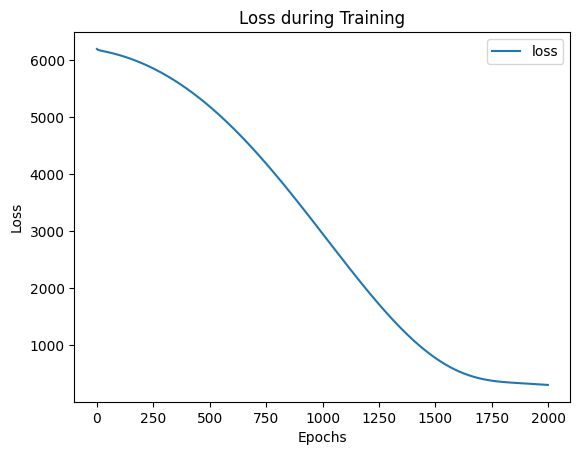

In [40]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [41]:
X_n1_1 = torch.tensor([[50]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 62.27897262573242
